# Tokenizer

The goal of this notebook is to explore tokenization methods for trading data.

## Normalising Prices

Exploring how to normalise prices while 

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

In [105]:
gbp = pd.read_csv('data/GBPUSD/hours.csv', index_col='time')
btc = pd.read_csv('data/BTCUSD/hours.csv', index_col='time')
gold = pd.read_csv('data/GOLD/hours.csv', index_col='time')

btc.index = pd.to_datetime(btc.index, unit='s')
gbp.index = pd.to_datetime(gbp.index, unit='s')
gold.index = pd.to_datetime(gold.index, unit='s')

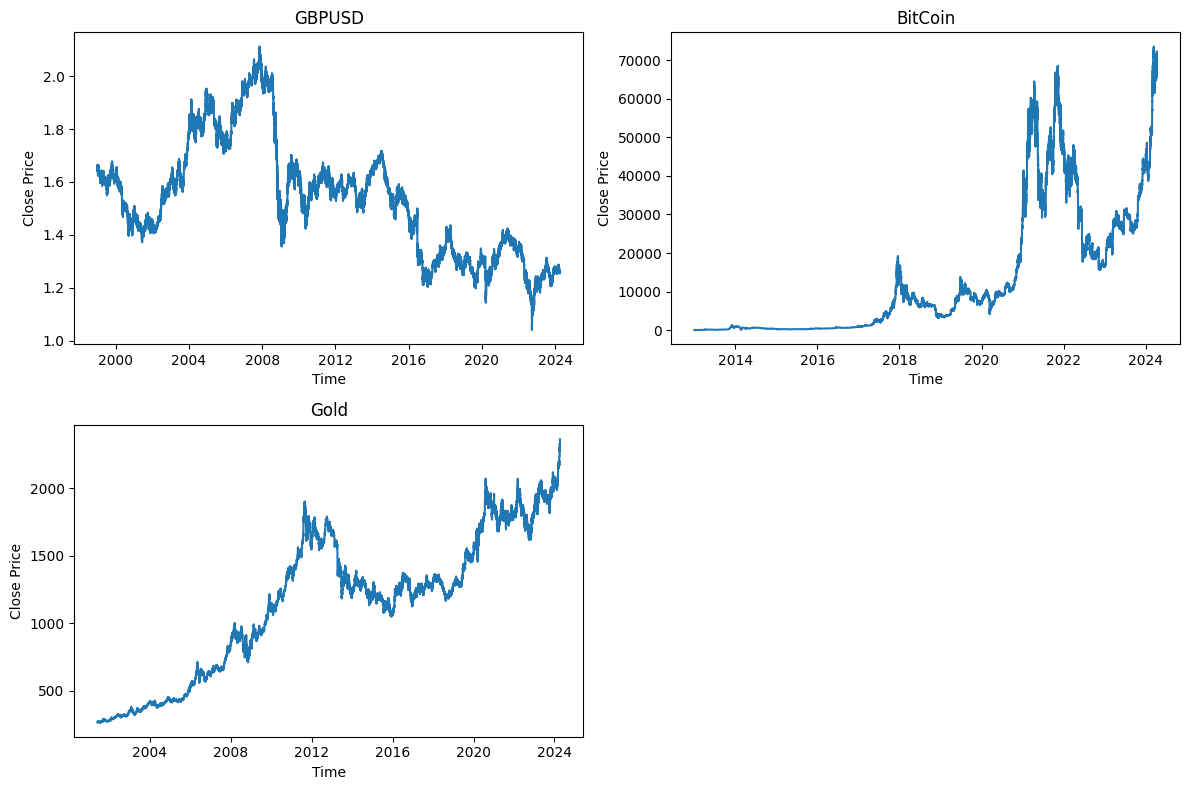

In [106]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plotting the first DataFrame
axs[0, 0].plot(gbp.index, gbp['close'])
axs[0, 0].set_title('GBPUSD')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Close Price')

# Plotting the second DataFrame
axs[0, 1].plot(btc.index, btc['close'])
axs[0, 1].set_title('BitCoin')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Close Price')

# Plotting the third DataFrame
axs[1, 0].plot(gold.index, gold['close'])
axs[1, 0].set_title('Gold')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Close Price')

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [107]:
print(f"GBPUSD: MAX {gbp.close.max()} MIN {gbp.close.min()} STD {gbp.close.std()}")
print(f"BTCUSD: MAX {btc.close.max()} MIN {btc.close.min()} STD {btc.close.std()}")
print(f"GOLD: MAX {gold.close.max()} MIN {gold.close.min()} STD {gold.close.std()}")

GBPUSD: MAX 2.1124 MIN 1.04003 STD 0.21864662638300733
BTCUSD: MAX 73577.2 MIN 13.28 STD 17250.714666562173
GOLD: MAX 2363.1 MIN 265.5 STD 340.7043671493367


## Normalising

In [108]:
import numpy as np

btc_max = np.max(btc.close)
btc_min = np.min(btc.close)

btc['normalized'] = (btc.close - btc_min) / (btc_max - btc_min)

gbp_max = np.max(gbp.close)
gbp_min = np.min(gbp.close)

gbp['normalized'] = (gbp.close - gbp_min) / (gbp_max - gbp_min)

gold_max = np.max(gold.close)
gold_min = np.min(gold.close)

gold['normalized'] = (gold.close - gold_min) / (gold_max - gold_min)


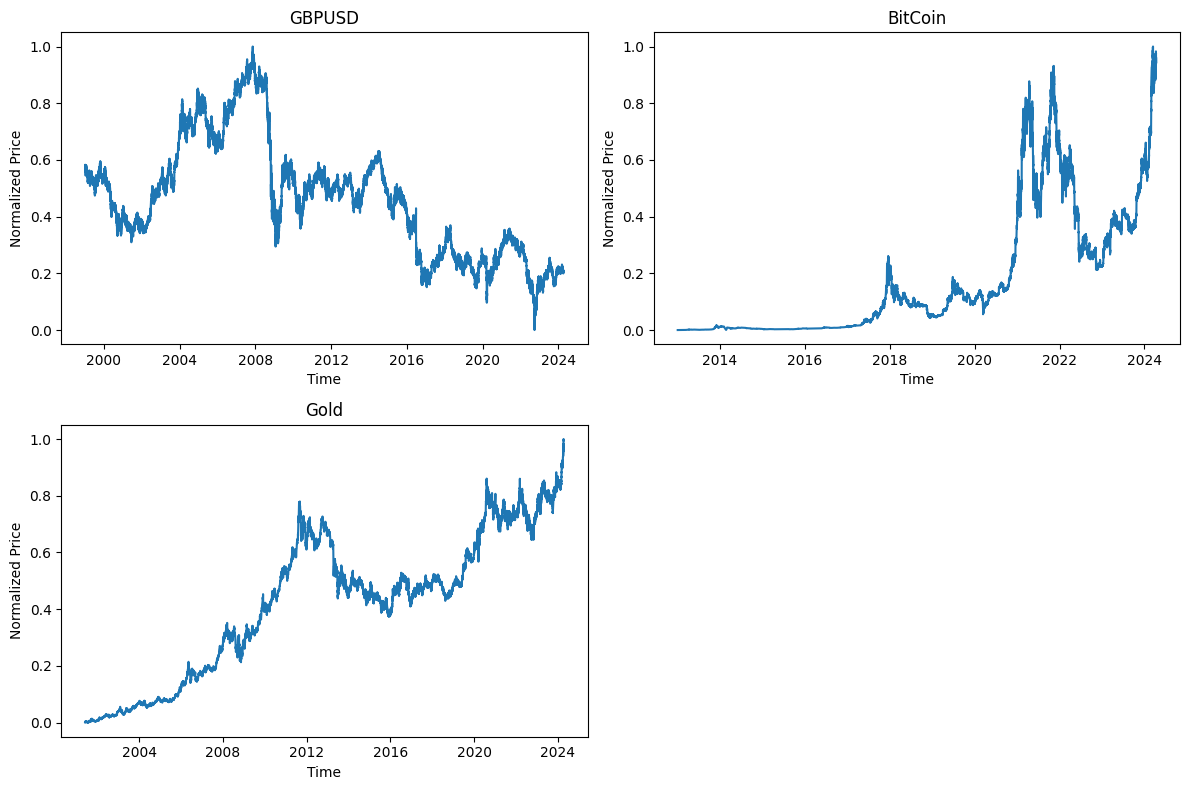

In [109]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plotting the first DataFrame
axs[0, 0].plot(gbp.index, gbp['normalized'])
axs[0, 0].set_title('GBPUSD')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Normalized Price')

# Plotting the second DataFrame
axs[0, 1].plot(btc.index, btc['normalized'])
axs[0, 1].set_title('BitCoin')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Normalized Price')

# Plotting the third DataFrame
axs[1, 0].plot(gold.index, gold['normalized'])
axs[1, 0].set_title('Gold')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Normalized Price')

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### Normalising Using Logs

In [110]:
import numpy as np

btc_log = np.log(btc.close)
btc_max = np.max(btc_log)
btc_min = np.min(btc_log)

btc['log_normalized'] = (btc_log - btc_min) / (btc_max - btc_min)

gbp_log = np.log(gbp.close)
gbp_max = np.max(gbp_log)
gbp_min = np.min(gbp_log)

gbp['log_normalized'] = (gbp_log - gbp_min) / (gbp_max - gbp_min)

gold_log = np.log(gold.close)
gold_max = np.max(gold_log)
gold_min = np.min(gold_log)

gold['log_normalized'] = (gold_log - gold_min) / (gold_max - gold_min)


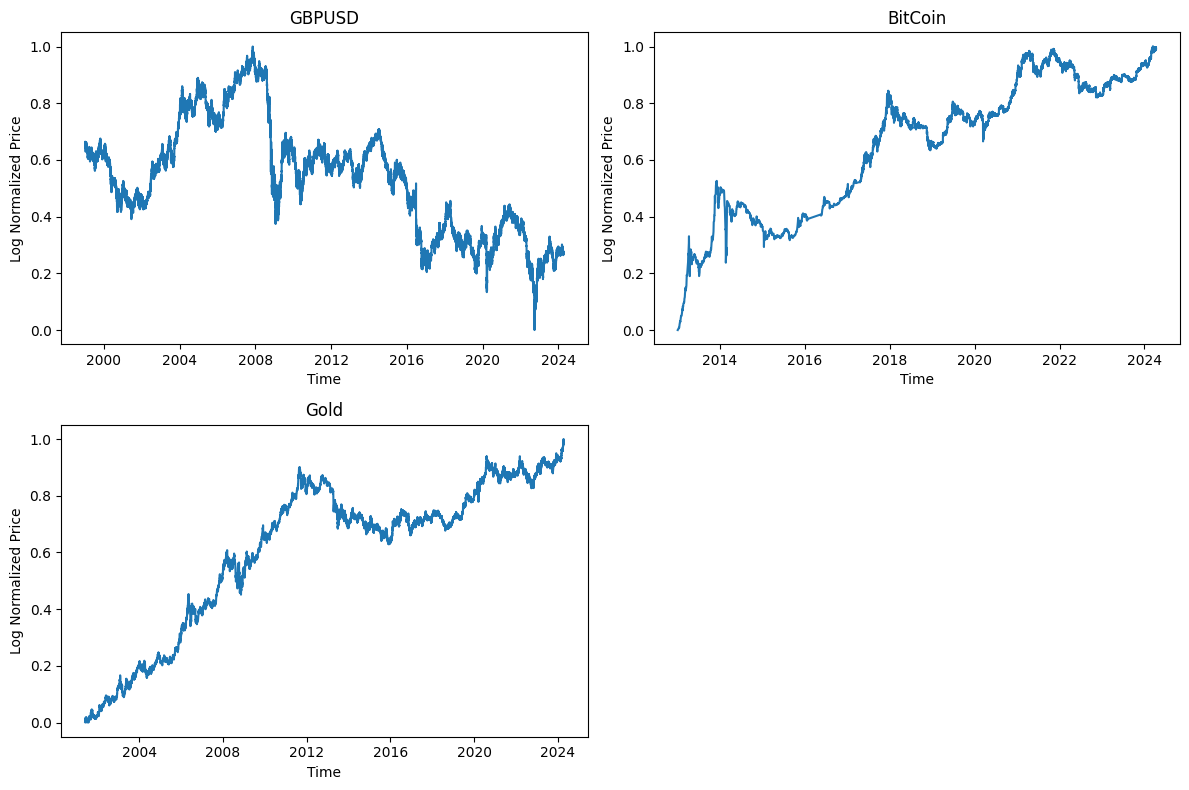

In [111]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plotting the first DataFrame
axs[0, 0].plot(gbp.index, gbp['log_normalized'])
axs[0, 0].set_title('GBPUSD')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Log Normalized Price')

# Plotting the second DataFrame
axs[0, 1].plot(btc.index, btc['log_normalized'])
axs[0, 1].set_title('BitCoin')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Log Normalized Price')

# Plotting the third DataFrame
axs[1, 0].plot(gold.index, gold['log_normalized'])
axs[1, 0].set_title('Gold')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Log Normalized Price')

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### Different Normalization Required

Log normalised still not ideal as the price still trends. Need to maintain more time period specific price action

## Sliding Window Normalization

In [112]:
def normalize_by_window(df, window_size=30):
    shifted_cols = []
    for x in range(1, window_size+1):
        col_name = f"close-{x}"
        df[col_name] = df['close'].shift(x)
        shifted_cols.append(col_name)

    comp_cols = shifted_cols + ['close']    
    df['window_normalized'] = (df['close'] - df[comp_cols].min(axis=1))/(df[comp_cols].max(axis=1) - df[comp_cols].min(axis=1))



In [113]:
sliding_window_size = 6

normalize_by_window(gbp, window_size=sliding_window_size)
normalize_by_window(btc, window_size=sliding_window_size)
normalize_by_window(gold, window_size=sliding_window_size)


gbp = gbp[sliding_window_size:]
btc = btc[sliding_window_size:]
gold = gold[sliding_window_size:]

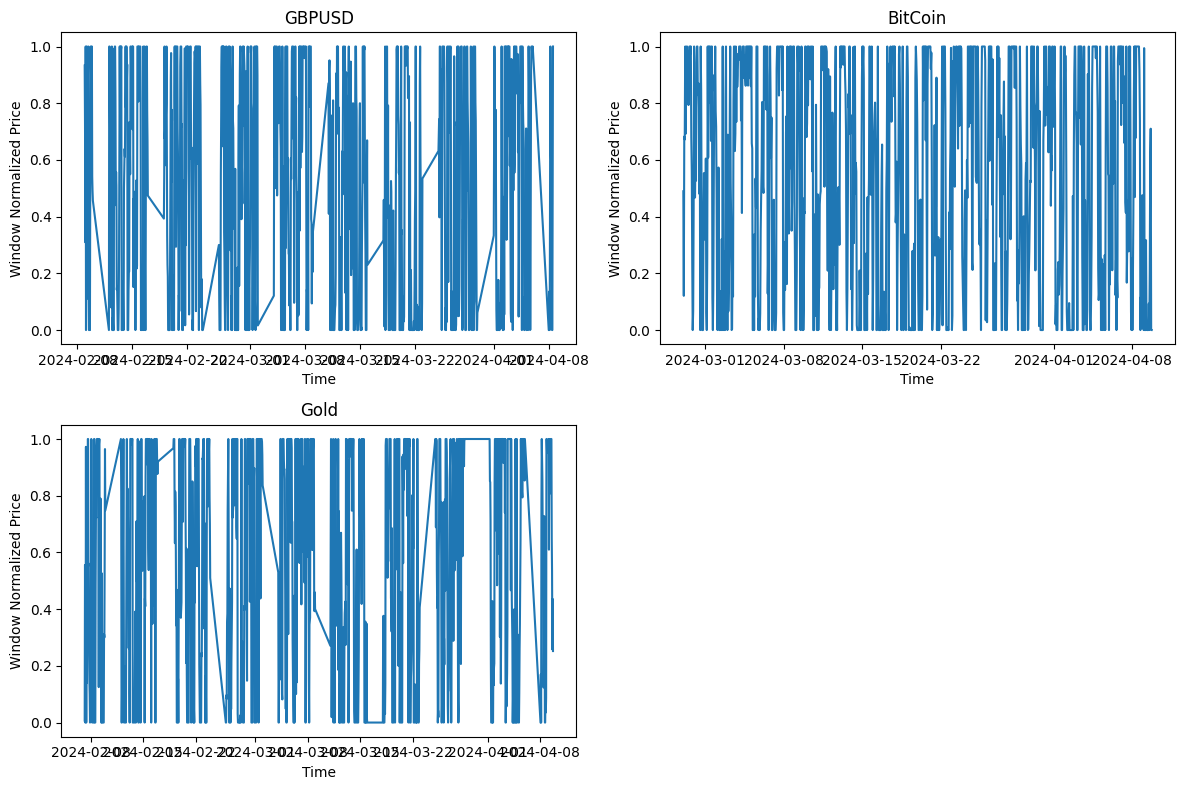

In [114]:
plot_size = 1000

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plotting the first DataFrame
axs[0, 0].plot(gbp[-plot_size:].index, gbp[-plot_size:]['window_normalized'])
axs[0, 0].set_title('GBPUSD')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Window Normalized Price')

# Plotting the second DataFrame
axs[0, 1].plot(btc[-plot_size:].index, btc[-plot_size:]['window_normalized'])
axs[0, 1].set_title('BitCoin')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Window Normalized Price')

# Plotting the third DataFrame
axs[1, 0].plot(gold[-plot_size:].index, gold[-plot_size:]['window_normalized'])
axs[1, 0].set_title('Gold')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Window Normalized Price')

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [115]:
def log_normalize_by_window(df, window_size=30):
    shifted_cols = []
    df['log'] = np.log(df['close'])
    for x in range(1, window_size+1):
        col_name = f"log-{x}"
        df[col_name] = df['log'].shift(x)
        shifted_cols.append(col_name)

    comp_cols = shifted_cols + ['log']    
    df['log_window_normalized'] = (df['log'] - df[comp_cols].min(axis=1))/(df[comp_cols].max(axis=1) - df[comp_cols].min(axis=1))



In [116]:

log_normalize_by_window(gbp, window_size=sliding_window_size)
log_normalize_by_window(btc, window_size=sliding_window_size)
log_normalize_by_window(gold, window_size=sliding_window_size)


gbp = gbp[sliding_window_size:]
btc = btc[sliding_window_size:]
gold = gold[sliding_window_size:]

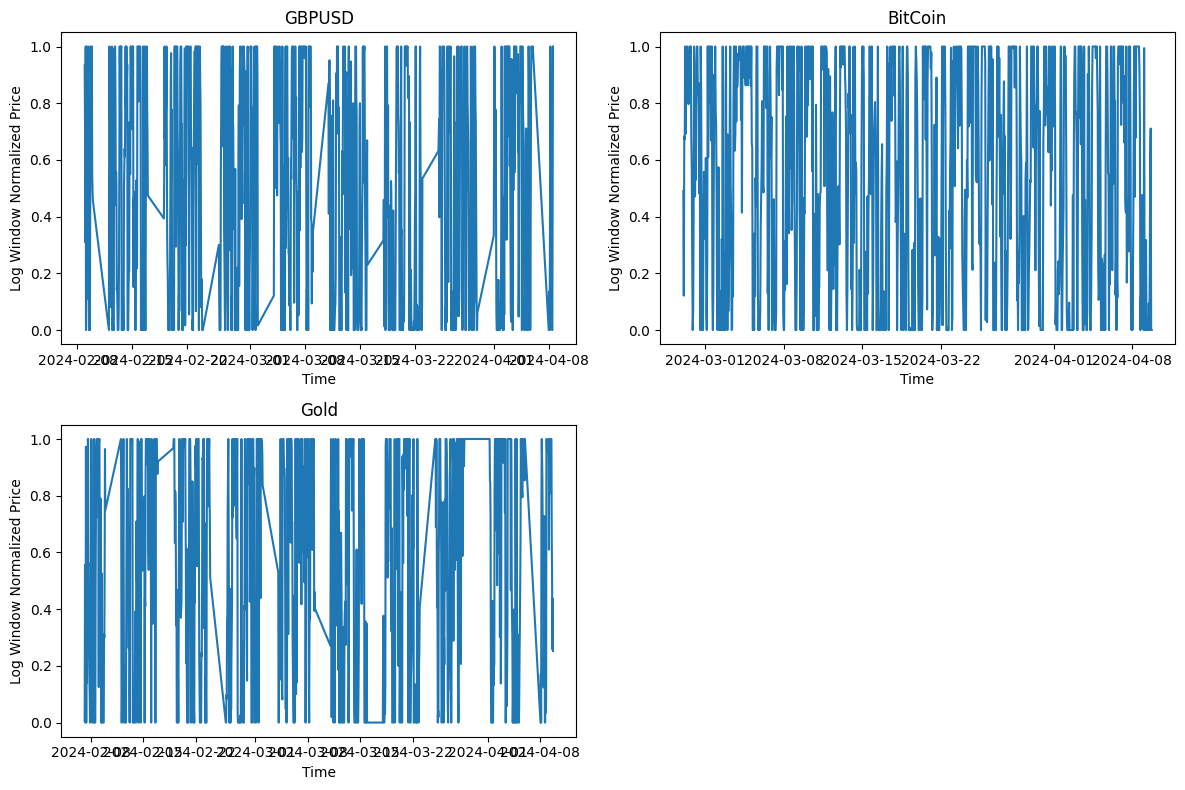

In [117]:
plot_size = 1000

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Plotting the first DataFrame
axs[0, 0].plot(gbp[-plot_size:].index, gbp[-plot_size:]['log_window_normalized'])
axs[0, 0].set_title('GBPUSD')
axs[0, 0].set_xlabel('Time')
axs[0, 0].set_ylabel('Log Window Normalized Price')

# Plotting the second DataFrame
axs[0, 1].plot(btc[-plot_size:].index, btc[-plot_size:]['log_window_normalized'])
axs[0, 1].set_title('BitCoin')
axs[0, 1].set_xlabel('Time')
axs[0, 1].set_ylabel('Log Window Normalized Price')

# Plotting the third DataFrame
axs[1, 0].plot(gold[-plot_size:].index, gold[-plot_size:]['log_window_normalized'])
axs[1, 0].set_title('Gold')
axs[1, 0].set_xlabel('Time')
axs[1, 0].set_ylabel('Log Window Normalized Price')

# Hide the empty subplot
axs[1, 1].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()